Supón que tienes un grafo con $N$ nodos y $M$ aristas representando una red social. Se observa que los nodos pueden pertenecer simultáneamente a varias comunidades. Diseña un esquema de clustering jerárquico que incorpore la estructura combinatoria del grafo (por ejemplo, mediante la matriz de adyacencia o medidas de centralidad). Implementa una versión simplificada de tu propuesta y evalúa sus resultados en un dataset simulado.

### Para comenzar creamos un dataset simulado de los nodos 

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Parámetros del grafo
N = 100  
prob_in = 0.3  # Probabilidad dentro de comunidades
prob_out = 0.03  # Probabilidad entre comunidades
n_comunidades = 3 # Número de comunidades

# Asignamos comunidades a nodos
np.random.seed(42)
etiquetas_comunidad = np.random.randint(1, n_comunidades+1, N)

# Inicializar grafo
G = nx.Graph()
G.add_nodes_from(range(N))

In [205]:
# Agregamos conexiones en base a las probabilidades definidas.
contador_aristas = 0
for i in range(N):
    for j in range(i + 1, N):
        if etiquetas_comunidad[i] == etiquetas_comunidad[j]:  # Misma comunidad
            if np.random.rand() < prob_in:
                G.add_edge(i, j)
                contador_aristas += 1
        else:  # Diferentes comunidades
            if np.random.rand() < prob_out:
                G.add_edge(i, j)
                contador_aristas += 1

print("M =",contador_aristas) # Número M de aristas

M = 636


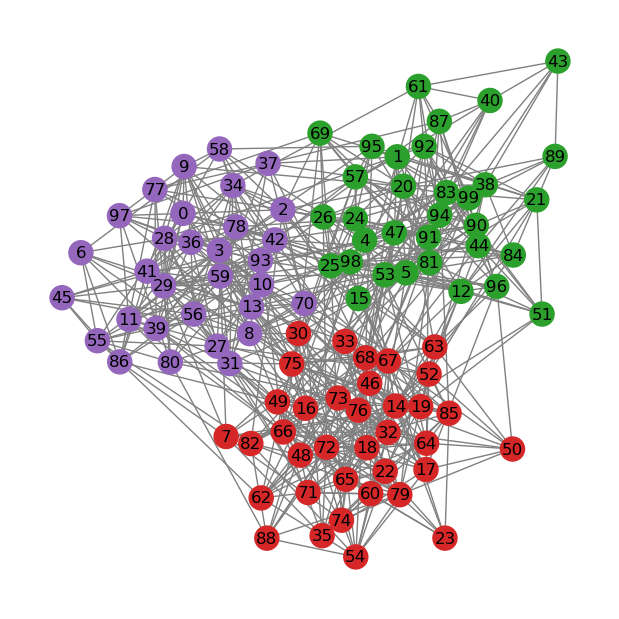

In [207]:
# Dibujar el grafo con colores por comunidad
plt.figure(figsize=(6,6))
colors = ["C"+str(etiquetas_comunidad[i]+1) for i in range(N)]
nx.draw(G, node_color=colors, with_labels=True, node_size=300, edge_color="gray")
plt.savefig("p2_grafo.pdf", format="pdf", bbox_inches="tight")

### Propuesta de matriz de disimilaridades

In [208]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns

# Obtener la matriz de adyacencia
A = nx.to_numpy_array(G)

# Calcular la matriz de distancia basada en caminos mínimos (Dijkstra) con mejoras
def dijkstra_distance(G):
    N = len(G.nodes)
    D = np.full((N, N), np.inf)  # Inicializamos con infinito
    np.fill_diagonal(D, 0)  # La distancia de un nodo consigo mismo es 0
    
    # Calcular distancias más cortas desde cada nodo
    for i in range(N):
        lengths = nx.single_source_shortest_path_length(G, i)
        for j, dist in lengths.items():
            D[i, j] = dist  # Asignamos la distancia real
    
    # Sustituir valores infinitos por un número grande pero finito
    max_finite = np.max(D[D < np.inf])  # Máxima distancia válida
    D[D == np.inf] = max_finite * 1.5  # Penalización controlada

    # Normalizar las distancias al rango [0,1] para hacerlas comparables con otras métricas
    D = (D - np.min(D)) / (np.max(D) - np.min(D)) if max_finite > 0 else D
    return D

# Aplicar la nueva función
D_dijkstra = dijkstra_distance(G)


### Aplicamos Clustering Jerarquico

In [ ]:
from sklearn.metrics import silhouette_score

# Evaluar los resultados usando el coeficiente de silueta
def evaluate_clustering(D, clusters, title):
    score = silhouette_score(D, clusters, metric='precomputed')
    #print(f"Coeficiente de silueta para {title}: {score:.4f}")
    return score


from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
# Aplicar clustering jerárquico con average-linkage
def hierarchical_clustering(D, title, threshold, metodo, n_clusters):
    D_condensed = squareform(D)  # Convertir a formato de vector de distancias
    linkage_matrix = linkage(D_condensed, method=metodo)
    '''
    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrix, labels=np.arange(N), leaf_rotation=90)
    plt.title(f"Dendrograma - {title}")
    plt.xlabel("Nodos")
    plt.ylabel("Distancia")
    plt.show()
    '''
    # Obtener clusters con un umbral de corte
    #clusters = fcluster(linkage_matrix, t=threshold, criterion='distance')
    # Obtener clusters con un número fijo de clusters
    clusters = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')

    return clusters
umbral_jaccard = 0.95
umbral_dijkstra = 0.62
num_max_clusters = 3


methods = ["average"] #, "complete","single"]
for method in methods:
    clusters_dijkstra = hierarchical_clustering(D_dijkstra, "Dijkstra", umbral_dijkstra, 'average', num_max_clusters)
    print(f"Silhouette para Jaccard-{method}: {score:.4f}")
    score = evaluate_clustering(D_dijkstra, clusters_dijkstra, f"Dijkstra-{method}")
    print(f"Silhouette para Dijkstra-{method}: {score:.4f}")



Silhouette para Jaccard-average: 0.0834
Silhouette para Dijkstra-average: 0.1465


In [ ]:
# Mostrar los clusters asignados
print("Comunidades originales:",etiquetas_comunidad)
print("Clusters obtenidos con Jaccard:", clusters_jaccard)
print("Clusters obtenidos con Dijkstra:", clusters_dijkstra)

print("Clusters Jaccard:", np.unique(clusters_jaccard))

print("Clusters Dijkstra:", np.unique(clusters_dijkstra))


Comunidades originales: [3 1 3 3 1 1 3 2 3 3 3 3 1 3 2 1 2 2 2 2 1 1 2 2 1 1 1 3 3 3 2 3 2 2 3 2 3
 3 1 3 1 3 3 1 1 3 2 1 2 2 2 1 2 1 2 3 3 1 3 3 2 1 2 2 2 2 2 2 2 1 3 2 2 2
 2 2 2 3 3 2 3 1 2 1 1 2 3 1 2 1 1 1 1 3 1 1 1 3 1 1]
Clusters obtenidos con Jaccard: [3 1 1 3 1 1 3 2 3 3 3 3 1 3 2 1 2 2 2 2 1 1 2 2 1 1 1 3 3 3 2 3 2 2 3 2 3
 3 1 3 1 3 3 1 1 3 2 1 2 2 2 1 2 1 2 3 3 1 3 3 2 1 2 2 2 2 2 2 2 1 3 2 2 2
 2 2 2 3 3 2 3 1 2 1 1 2 3 1 2 1 1 1 1 3 1 1 1 3 1 1]
Clusters obtenidos con Dijkstra: [1 2 1 2 3 3 1 3 3 1 1 1 2 1 3 2 3 3 3 3 2 2 3 3 2 1 1 3 1 1 3 1 3 3 1 3 1
 1 3 1 2 1 2 2 2 1 3 2 3 3 3 3 3 3 3 1 1 2 1 1 3 2 3 2 3 3 3 3 3 1 1 3 3 3
 3 1 3 1 2 3 1 2 3 2 2 3 1 2 3 2 2 2 2 1 2 2 2 1 2 2]
Clusters Jaccard: [1 2 3]
Clusters Dijkstra: [1 2 3]


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Crear la matriz de confusión
conf_matrix_jaccard = confusion_matrix(etiquetas_comunidad, clusters_jaccard)
conf_matrix_dijkstra = confusion_matrix(etiquetas_comunidad, clusters_dijkstra)

# Imprimir las matrices de confusión
print("Matriz de Confusión - Jaccard:")
print(conf_matrix_jaccard)
print("\nMatriz de Confusión - Dijkstra:")
print(conf_matrix_dijkstra)

# La idea es usar estas matrices de confusión para decidir cómo reasignar las etiquetas
# Por ejemplo, podemos mapear las etiquetas de los clusters de Jaccard o Dijkstra a las originales


Matriz de Confusión - Jaccard:
[[33  0  0]
 [ 0 36  0]
 [ 1  0 30]]

Matriz de Confusión - Dijkstra:
[[ 3 25  5]
 [ 1  1 34]
 [26  3  2]]


In [ ]:
# Reasignar las etiquetas de acuerdo con la matriz de confusión de Jaccard
# Mapeo basado en la mayor coincidencia observada
mapping_jaccard = {1: 3, 2: 2, 3: 1}  # 1->2, 2->3, 3->1

clusters_jaccard_reordered = np.array([mapping_jaccard[label] for label in clusters_jaccard])

print("Clusters Jaccard Reordenados:")
print(clusters_jaccard_reordered)
print("Comunidades originales:")
print(etiquetas_comunidad)

Clusters Jaccard Reordenados:
[1 3 3 1 3 3 1 2 1 1 1 1 3 1 2 3 2 2 2 2 3 3 2 2 3 3 3 1 1 1 2 1 2 2 1 2 1
 1 3 1 3 1 1 3 3 1 2 3 2 2 2 3 2 3 2 1 1 3 1 1 2 3 2 2 2 2 2 2 2 3 1 2 2 2
 2 2 2 1 1 2 1 3 2 3 3 2 1 3 2 3 3 3 3 1 3 3 3 1 3 3]
Comunidades originales:
[3 1 3 3 1 1 3 2 3 3 3 3 1 3 2 1 2 2 2 2 1 1 2 2 1 1 1 3 3 3 2 3 2 2 3 2 3
 3 1 3 1 3 3 1 1 3 2 1 2 2 2 1 2 1 2 3 3 1 3 3 2 1 2 2 2 2 2 2 2 1 3 2 2 2
 2 2 2 3 3 2 3 1 2 1 1 2 3 1 2 1 1 1 1 3 1 1 1 3 1 1]


In [ ]:
# Reasignar las etiquetas de acuerdo con la matriz de confusión de Dijkstra
# Mapeo basado en la mayor coincidencia observada
mapping_dijkstra = {1: 1, 2: 2, 3: 3}  # 1->3, 2->1, 3->2

clusters_dijkstra_reordered = np.array([mapping_dijkstra[label] for label in clusters_dijkstra])

print("Clusters Dijkstra Reordenados:")
print(clusters_dijkstra_reordered)
print("Comunidades originales:")
print(etiquetas_comunidad)

Clusters Dijkstra Reordenados:
[1 2 1 2 3 3 1 3 3 1 1 1 2 1 3 2 3 3 3 3 2 2 3 3 2 1 1 3 1 1 3 1 3 3 1 3 1
 1 3 1 2 1 2 2 2 1 3 2 3 3 3 3 3 3 3 1 1 2 1 1 3 2 3 2 3 3 3 3 3 1 1 3 3 3
 3 1 3 1 2 3 1 2 3 2 2 3 1 2 3 2 2 2 2 1 2 2 2 1 2 2]
Comunidades originales:
[3 1 3 3 1 1 3 2 3 3 3 3 1 3 2 1 2 2 2 2 1 1 2 2 1 1 1 3 3 3 2 3 2 2 3 2 3
 3 1 3 1 3 3 1 1 3 2 1 2 2 2 1 2 1 2 3 3 1 3 3 2 1 2 2 2 2 2 2 2 1 3 2 2 2
 2 2 2 3 3 2 3 1 2 1 1 2 3 1 2 1 1 1 1 3 1 1 1 3 1 1]


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

def reorder_clusters(community_labels, predicted_clusters):
    """
    Reasigna los clusters para que coincidan lo mejor posible con las etiquetas originales.

    Parámetros:
        community_labels (array): Etiquetas de comunidad originales.
        predicted_clusters (array): Clusters obtenidos del algoritmo de clustering.

    Retorna:
        clusters_reordered (array): Clusters reasignados según la mejor correspondencia.
        conf_matrix (array): Matriz de confusión entre etiquetas originales y clusters.
    """
    # Obtener matriz de confusión
    conf_matrix = confusion_matrix(community_labels, predicted_clusters)

    # Encontrar la mejor asignación de clusters a etiquetas originales
    mapping = {}
    used_clusters = set()
    
    for true_label in range(conf_matrix.shape[0]):  # Para cada comunidad real
        # Encuentra la columna con mayor valor en esta fila (mejor coincidencia)
        best_cluster = np.argmax(conf_matrix[true_label])
        
        # Si el cluster ya fue asignado, buscar otra opción
        while best_cluster in used_clusters:
            conf_matrix[true_label, best_cluster] = -1  # Anular esta opción
            best_cluster = np.argmax(conf_matrix[true_label])
        
        # Asignar el mejor cluster encontrado a la comunidad real
        mapping[best_cluster + 1] = true_label + 1  # Ajuste por indexación en Python
        used_clusters.add(best_cluster)
    
    # Reasignar clusters con el mapeo obtenido
    clusters_reordered = np.array([mapping[label] for label in predicted_clusters])

    return clusters_reordered, conf_matrix

# Aplicar a los clusters de Jaccard y Dijkstra
clusters_jaccard_reordered, conf_matrix_jaccard = reorder_clusters(etiquetas_comunidad, clusters_jaccard)
clusters_dijkstra_reordered, conf_matrix_dijkstra = reorder_clusters(etiquetas_comunidad, clusters_dijkstra)

# Mostrar resultados
print("Matriz de Confusión - Jaccard:\n", conf_matrix_jaccard)
print("\nClusters Jaccard Reordenados:\n", clusters_jaccard_reordered)

print("\nMatriz de Confusión - Dijkstra:\n", conf_matrix_dijkstra)
print("\nClusters Dijkstra Reordenados:\n", clusters_dijkstra_reordered)


Matriz de Confusión - Jaccard:
 [[33  0  0]
 [ 0 36  0]
 [ 1  0 30]]

Clusters Jaccard Reordenados:
 [3 1 1 3 1 1 3 2 3 3 3 3 1 3 2 1 2 2 2 2 1 1 2 2 1 1 1 3 3 3 2 3 2 2 3 2 3
 3 1 3 1 3 3 1 1 3 2 1 2 2 2 1 2 1 2 3 3 1 3 3 2 1 2 2 2 2 2 2 2 1 3 2 2 2
 2 2 2 3 3 2 3 1 2 1 1 2 3 1 2 1 1 1 1 3 1 1 1 3 1 1]

Matriz de Confusión - Dijkstra:
 [[ 3 25  5]
 [ 1  1 34]
 [26  3  2]]

Clusters Dijkstra Reordenados:
 [3 1 3 1 2 2 3 2 2 3 3 3 1 3 2 1 2 2 2 2 1 1 2 2 1 3 3 2 3 3 2 3 2 2 3 2 3
 3 2 3 1 3 1 1 1 3 2 1 2 2 2 2 2 2 2 3 3 1 3 3 2 1 2 1 2 2 2 2 2 3 3 2 2 2
 2 3 2 3 1 2 3 1 2 1 1 2 3 1 2 1 1 1 1 3 1 1 1 3 1 1]


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Crear la matriz de confusión
conf_matrix_jaccard = confusion_matrix(etiquetas_comunidad, clusters_jaccard_reordered)
conf_matrix_dijkstra = confusion_matrix(etiquetas_comunidad, clusters_dijkstra_reordered)

# Imprimir las matrices de confusión
print("Matriz de Confusión - Jaccard:")
print(conf_matrix_jaccard)
print("\nMatriz de Confusión - Dijkstra:")
print(conf_matrix_dijkstra)

# La idea es usar estas matrices de confusión para decidir cómo reasignar las etiquetas
# Por ejemplo, podemos mapear las etiquetas de los clusters de Jaccard o Dijkstra a las originales

Matriz de Confusión - Jaccard:
[[33  0  0]
 [ 0 36  0]
 [ 1  0 30]]

Matriz de Confusión - Dijkstra:
[[25  5  3]
 [ 1 34  1]
 [ 3  2 26]]


### Visualizacion de los clusters obtenidos

Visualización del grafo para Jaccard

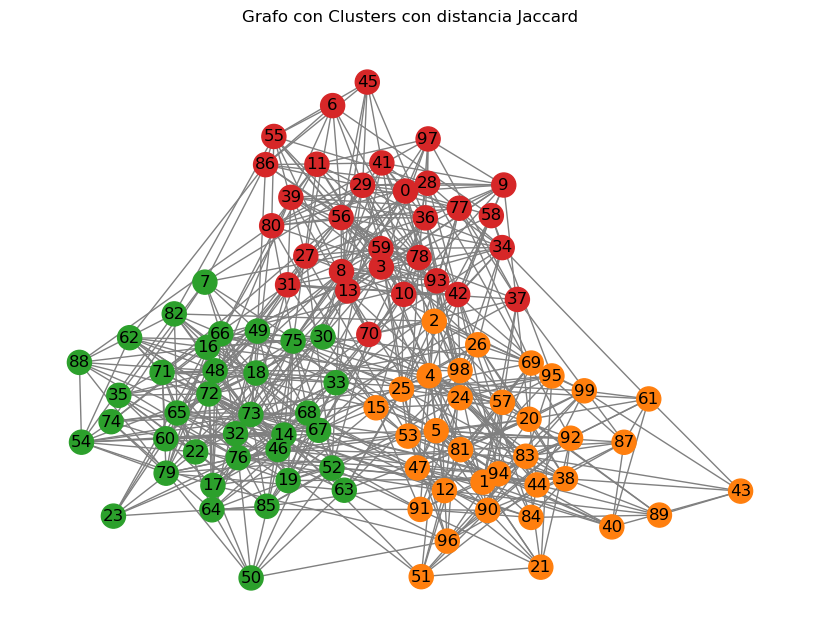

In [16]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_graph_with_clusters(G, clusters):
    # Colorear los nodos según el cluster al que pertenecen
    colors = [f"C{cluster}" for cluster in clusters]  # 'C{cluster-1}' para obtener colores únicos para cada cluster

    # Dibujar el grafo con los colores asignados a cada nodo
    plt.figure(figsize=(8, 6))
    nx.draw(G, node_color=colors, with_labels=True, node_size=300, edge_color="gray", cmap=plt.cm.rainbow)
    plt.title("Grafo con Clusters con distancia Jaccard")
    plt.show()

# Asumiendo que ya tienes tu grafo G y tus clusters (ej. clusters_jaccard o clusters_dijkstra)
draw_graph_with_clusters(G, clusters_jaccard_reordered)


Visualización del grafo para Dijkstra

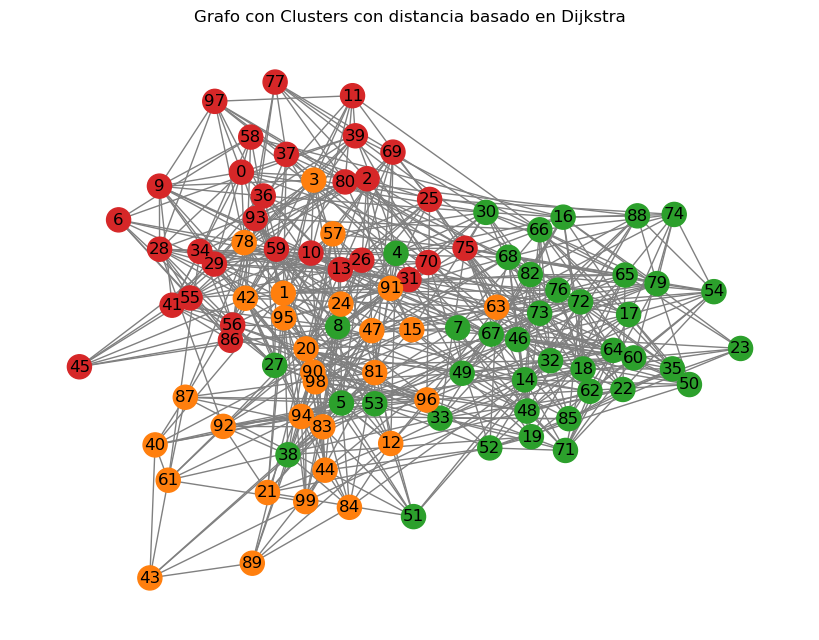

In [23]:
def draw_graph_with_clusters(G, clusters):
    # Colorear los nodos según el cluster al que pertenecen
    colors = [f"C{cluster}" for cluster in clusters]  # 'C{cluster-1}' para obtener colores únicos para cada cluster

    # Dibujar el grafo con los colores asignados a cada nodo
    plt.figure(figsize=(8, 6))
    nx.draw(G, node_color=colors, with_labels=True, node_size=300, edge_color="gray", cmap=plt.cm.rainbow)
    plt.title("Grafo con Clusters con distancia basado en Dijkstra")
    plt.show()

# Asumiendo que ya tienes tu grafo G y tus clusters (ej. clusters_jaccard o clusters_dijkstra)
draw_graph_with_clusters(G, clusters_dijkstra_reordered)

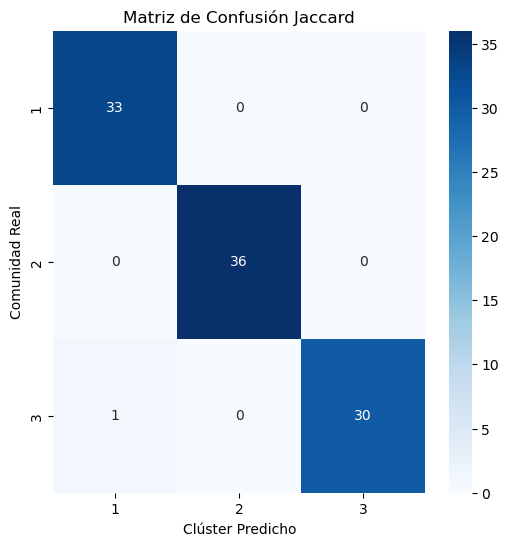

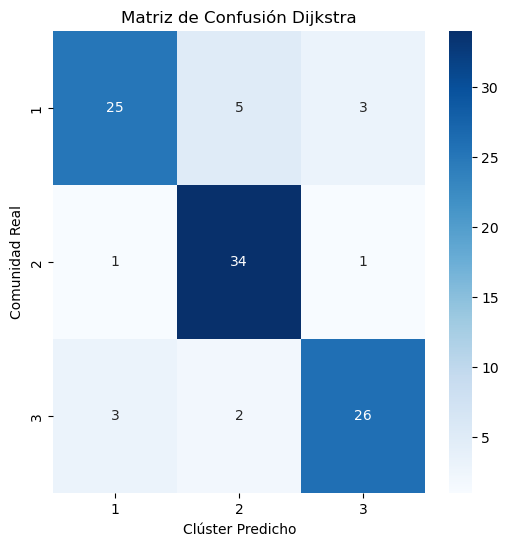

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(true_labels, predicted_labels, title="Matriz de Confusión"):
    cm = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(true_labels), yticklabels=np.unique(true_labels))
    plt.title(title)
    plt.xlabel('Clúster Predicho')
    plt.ylabel('Comunidad Real')
    plt.show()

# Comparar los clusters obtenidos con las comunidades reales ajustadas
plot_confusion_matrix(etiquetas_comunidad, clusters_jaccard_reordered, title="Matriz de Confusión Jaccard")
plot_confusion_matrix(etiquetas_comunidad, clusters_dijkstra_reordered, title="Matriz de Confusión Dijkstra")
